# Advanced NumField Operations

This notebook demonstrates advanced operations available in the NumField package, including field manipulation, transformations, and I/O operations. We'll use the convenience functions from the `examples` module to quickly set up test data.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from numfield import CartesianMesh, CartesianField, Fields
from numfield.examples import mesh_2d, mesh_3d, field_gaussian, field_sinusoidal, fields_collection

## 1. Using Example Meshes and Fields

The `examples` module provides factory functions for quickly creating common test meshes and fields.

In [3]:
# Create example meshes
mesh_2 = mesh_2d(nx=30, ny=20)
print(f"2D Mesh: {mesh_2}")

mesh_3 = mesh_3d(nx=15, ny=15, nz=10)
print(f"\n3D Mesh: {mesh_3}")

2D Mesh: CartesianMesh (30, 20):
x0: [0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333 0.66666667 0.7        0.73333333 0.76666667
 0.8        0.83333333 0.86666667 0.9        0.93333333 0.96666667
 1.        ]
x1: [0.    0.075 0.15  0.225 0.3   0.375 0.45  0.525 0.6   0.675 0.75  0.825
 0.9   0.975 1.05  1.125 1.2   1.275 1.35  1.425 1.5  ]


3D Mesh: CartesianMesh (15, 15, 10):
x0: [0.         0.06666667 0.13333333 0.2        0.26666667 0.33333333
 0.4        0.46666667 0.53333333 0.6        0.66666667 0.73333333
 0.8        0.86666667 0.93333333 1.        ]
x1: [0.         0.06666667 0.13333333 0.2        0.26666667 0.33333333
 0.4        0.46666667 0.53333333 0.6        0.66666667 0.73333333
 0.8        0.86666667 0.93333333 1.        ]
x2: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]



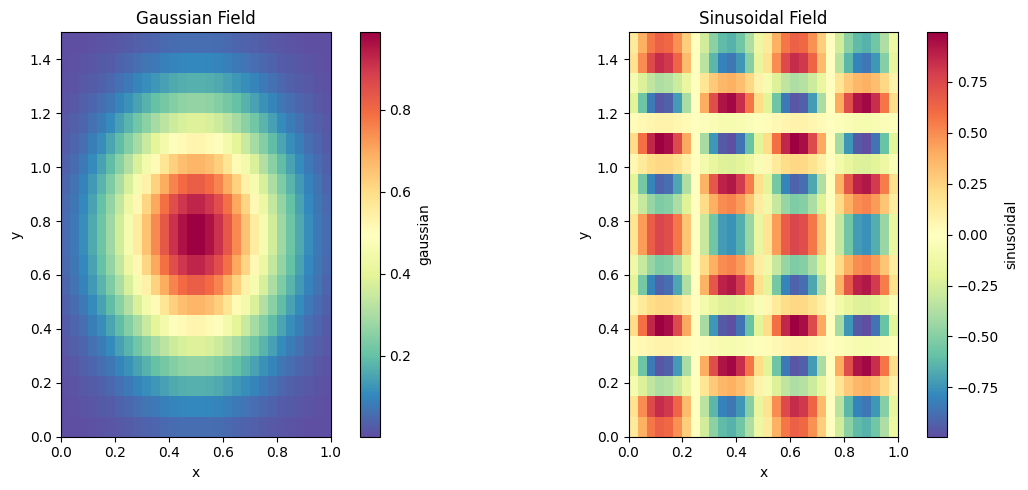

In [4]:
# Create example fields with different patterns
gaussian_field = field_gaussian(mesh_2, name="gaussian")
sinusoidal_field = field_sinusoidal(mesh_2, name="sinusoidal", frequencies=(2.0, 3.0))

# Plot both fields
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
gaussian_field.plot(ax=ax1)
ax1.set_title("Gaussian Field")
sinusoidal_field.plot(ax=ax2)
ax2.set_title("Sinusoidal Field")
plt.tight_layout()

## 2. Transpose Operations

Transpose both mesh axes and field values simultaneously.

In [12]:
# Create a 3D field for transpose demonstration
mesh_3 = mesh_3d(nx=10, ny=15, nz=8)
field_3d = field_gaussian(mesh_3, name="gaussian_3d")

print(f"Original field shape: {field_3d.shape}")
print(f"Original axes: {field_3d.mesh.axes_names}")

# Transpose: reverse all axes (default behavior)
field_transposed = field_3d.transpose()
print(f"\nTransposed field shape: {field_transposed.shape}")
print(f"Transposed axes: {field_transposed.mesh.axes_names}")

Original field shape: (10, 15, 8)
Original axes: ['x', 'y', 'z']

Transposed field shape: (8, 15, 10)
Transposed axes: ['z', 'y', 'x']


In [13]:
# Custom axis permutation: (2, 0, 1) means z->x, x->y, y->z
field_custom = field_3d.transpose((2, 0, 1))
print(f"Custom transpose shape: {field_custom.shape}")
print(f"Custom transpose axes: {field_custom.mesh.axes_names}")

# Verify values are transposed correctly
assert np.allclose(field_custom.values, np.transpose(field_3d.values, (2, 0, 1)))
print("\nValues transposed correctly !")

Custom transpose shape: (8, 10, 15)
Custom transpose axes: ['z', 'x', 'y']

Values transposed correctly !


## 3. Rotation by 90 Degrees

Rotate both mesh and field values by multiples of 90 degrees.

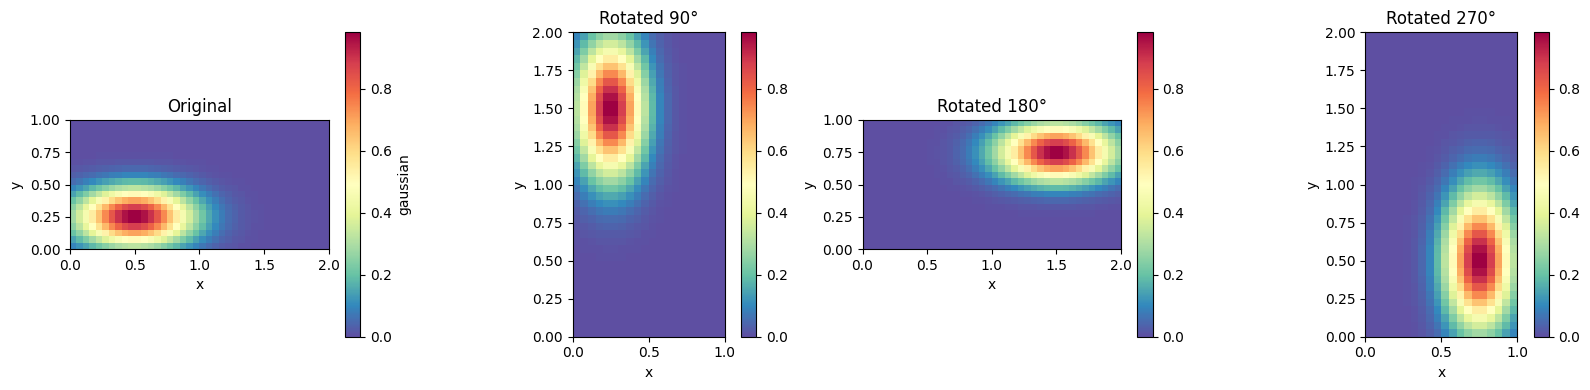

In [14]:
# Create an asymmetric field to visualize rotation
mesh_rect = mesh_2d(nx=40, ny=20, lx=2.0, ly=1.0)
asymmetric_field = field_gaussian(mesh_rect, center=(0.5, 0.25), sigma=(0.3, 0.15))

# Plot original
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
asymmetric_field.plot(ax=axes[0])
axes[0].set_title("Original")

# Rotate 90 degrees counter-clockwise
rotated_90 = asymmetric_field.rot90(1)
rotated_90.plot(ax=axes[1])
axes[1].set_title("Rotated 90°")

# Rotate 180 degrees
rotated_180 = asymmetric_field.rot90(2)
rotated_180.plot(ax=axes[2])
axes[2].set_title("Rotated 180°")

# Rotate 270 degrees
rotated_270 = asymmetric_field.rot90(3)
rotated_270.plot(ax=axes[3])
axes[3].set_title("Rotated 270°")

plt.tight_layout()

## 4. Field Slicing

Extract sub-fields while preserving mesh information.

Original 3D field shape: (20, 20, 15)
Sliced 2D field shape: (20, 20)
Sliced field mesh dimensions: 2


Text(0.5, 1.0, 'Z-slice at index 7')

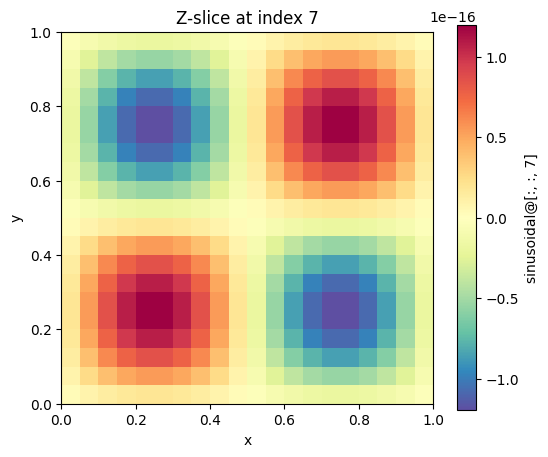

In [ ]:
# Create a 3D field
mesh_3 = mesh_3d(nx=20, ny=20, nz=15)
field_3d = field_sinusoidal(mesh_3, frequencies=(1.0, 1.0, 1.0))

# Extract a 2D slice at z=7
slice_2d = field_3d[:, :, 7]
print(f"Original 3D field shape: {field_3d.shape}")
print(f"Sliced 2D field shape: {slice_2d.shape}")
print(f"Sliced field mesh dimensions: {slice_2d.mesh.ndim}") # pyright: ignore[reportAttributeAccessIssue]

# Plot the slice
fig, ax = plt.subplots(figsize=(6, 5))
slice_2d.plot(ax=ax)
ax.set_title(f"Z-slice at index 7")

In [16]:
# Extract a sub-region
sub_field = field_3d[5:15, 5:15, 5:10]
print(f"\nSub-field shape: {sub_field.shape}")
print(f"Original x-range: {field_3d.mesh.x[0]:.2f} to {field_3d.mesh.x[-1]:.2f}")
print(f"Sub-field x-range: {sub_field.mesh.x[0]:.2f} to {sub_field.mesh.x[-1]:.2f}")


Sub-field shape: (10, 10, 5)
Original x-range: 0.00 to 1.00
Sub-field x-range: 0.25 to 0.75


## 5. Field Normalization

Normalize fields so their sum equals a specified value.

In [17]:
# Create a field
mesh = mesh_2d(nx=30, ny=30)
field = field_gaussian(mesh, amplitude=100)

print(f"Original field sum: {field.sum():.4f}")

# Normalize to sum = 1 (probability distribution)
normalized = field.normalize()
print(f"Normalized field sum: {normalized.sum():.4f}")

# Normalize to sum = 10
normalized_10 = field.normalize(10.0)
print(f"Normalized (sum=10) field sum: {normalized_10.sum():.4f}")

# Verify scaling relationship
assert np.allclose(normalized_10.values, 10 * normalized.values)
print("\nScaling verified: normalized_10 = 10 × normalized")

Summing intensive field values has ambiguous meaning, maybe you intend to apply summation on the values * volumes instead ?
Summing intensive field values has ambiguous meaning, maybe you intend to apply summation on the values * volumes instead ?
Summing intensive field values has ambiguous meaning, maybe you intend to apply summation on the values * volumes instead ?
Summing intensive field values has ambiguous meaning, maybe you intend to apply summation on the values * volumes instead ?
Summing intensive field values has ambiguous meaning, maybe you intend to apply summation on the values * volumes instead ?


Original field sum: 22065.6388
Normalized field sum: 1.0000
Normalized (sum=10) field sum: 10.0000

Scaling verified: normalized_10 = 10 × normalized


## 6. Intensive/Extensive Conversion

Convert between intensive (density-like) and extensive (mass-like) field representations.

In [18]:
# Create an intensive field (e.g., density)
mesh = mesh_2d(nx=20, ny=20, lx=10.0, ly=10.0)
density = field_gaussian(mesh, name="density", amplitude=1000, intensive=True)

print(f"Density field (intensive): {density}")
print(f"  Sum of values: {density.sum():.2f}")
print(f"  Mean value: {density.mean():.2f}")

# Convert to extensive (multiply by cell volumes)
mass = density.to_extensive()
print(f"\nMass field (extensive): {mass}")
print(f"  Sum of values: {mass.sum():.2f} (total mass)")

# Convert back to intensive
density_recovered = mass.to_intensive()
print(f"\nRecovered density: {density_recovered}")
print(f"  Mean value: {density_recovered.mean():.2f}")

# Verify round-trip
assert np.allclose(density.values, density_recovered.values)
print("\nRound-trip conversion verified!")

Summing intensive field values has ambiguous meaning, maybe you intend to apply summation on the values * volumes instead ?


Density field (intensive): intensive CartesianField(density, shape=(20, 20))
  Sum of values: 98094.47
  Mean value: 245.24

Mass field (extensive): extensive CartesianField(density, shape=(20, 20))
  Sum of values: 24523.62 (total mass)

Recovered density: intensive CartesianField(density, shape=(20, 20))
  Mean value: 245.24

Round-trip conversion verified!


## 7. NumPy Operations on Fields

Apply NumPy functions while preserving field structure.

In [19]:
# Create a field
mesh = mesh_2d(nx=40, ny=40)
field = field_sinusoidal(mesh, frequencies=(2.0, 2.0))

# Mathematical operations preserve field structure
squared = np.square(field)
print(f"Original: {field}")
print(f"Squared: {squared}")
print(f"  Type: {type(squared)}")

# Trigonometric functions
sin_field = np.sin(field * np.pi)
print(f"\nsin(field × π): min={sin_field.min():.4f}, max={sin_field.max():.4f}")

# Statistical operations with axis parameter
mean_x = field.mean(axis=0)
print(f"\nMean along axis 0: shape={mean_x.shape}, mesh.ndim={mean_x.mesh.ndim}")

Original: intensive CartesianField(sinusoidal, shape=(40, 40))
Squared: intensive CartesianField(sinusoidal, shape=(40, 40))
  Type: <class 'field.fields.CartesianField'>

sin(field × π): min=-0.9987, max=0.9987

Mean along axis 0: shape=(40,), mesh.ndim=1


Combined field (f1 + 2×f2): intensive CartesianField(f1, shape=(40, 40))


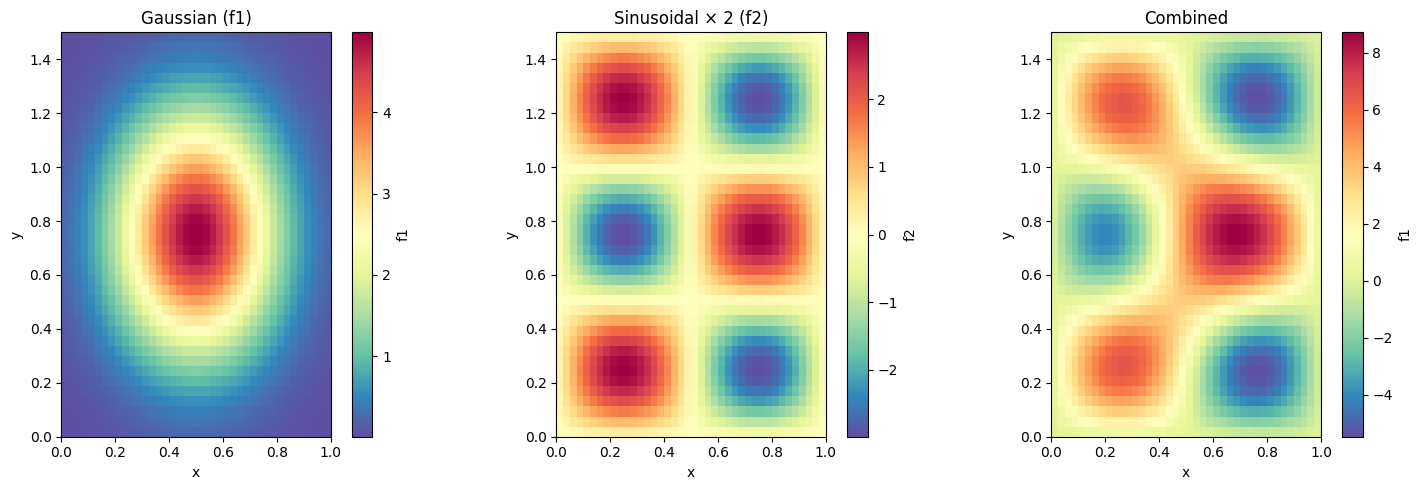

In [20]:
# Arithmetic operations between fields
field1 = field_gaussian(mesh, amplitude=5, name="f1")
field2 = field_sinusoidal(mesh, amplitude=3, name="f2")

combined = field1 + field2 * 2
print(f"Combined field (f1 + 2×f2): {combined}")

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
field1.plot(ax=axes[0])
axes[0].set_title("Gaussian (f1)")
field2.plot(ax=axes[1])
axes[1].set_title("Sinusoidal × 2 (f2)")
combined.plot(ax=axes[2])
axes[2].set_title("Combined")
plt.tight_layout()

## 8. HDF5 Input/Output

Save and load meshes, fields, and field collections to/from HDF5 files.

In [21]:
# Create a temporary directory for HDF5 files
tmp_dir = Path("./tmp_hdf5_demo")
tmp_dir.mkdir(exist_ok=True)

# Save and load a mesh
mesh_original = mesh_3d(nx=10, ny=15, nz=8)
mesh_file = tmp_dir / "mesh_demo.h5"
mesh_original.to_hdf(str(mesh_file))

mesh_loaded = CartesianMesh.from_hdf(str(mesh_file))

print(f"Original mesh: {mesh_original.shape}")
print(f"Loaded mesh: {mesh_loaded.shape}")
print(f"Meshes equal: {mesh_original == mesh_loaded}")

Original mesh: (10, 15, 8)
Loaded mesh: (10, 15, 8)
Meshes equal: True


In [22]:
# Save and load a field
field_original = field_gaussian(mesh_2d(nx=30, ny=30), amplitude=42.0)
field_file = tmp_dir / "field_demo.h5"
field_original.to_hdf(str(field_file))

field_loaded = CartesianField.from_hdf(str(field_file))

print(f"Original field: {field_original}")
print(f"Loaded field: {field_loaded}")
print(f"Fields equal: {field_original == field_loaded}")

Original field: intensive CartesianField(gaussian, shape=(30, 30))
Loaded field: intensive CartesianField(gaussian, shape=(30, 30))
Fields equal: True


In [23]:
# Save and load a Fields container (multiple fields)
mesh = mesh_2d(nx=25, ny=25)
fields_original = fields_collection(mesh)

print(f"Original Fields: {fields_original}")
print(f"  Field names: {fields_original.data_names}")

# Save to HDF5
fields_file = tmp_dir / "fields_demo.h5"
fields_original.to_hdf(str(fields_file))

# Load from HDF5
fields_loaded = Fields.from_hdf(str(fields_file))

print(f"\nLoaded Fields: {fields_loaded}")
print(f"  Field names: {fields_loaded.data_names}")
print(f"  Meshes equal: {fields_original.mesh == fields_loaded.mesh}")

# Verify each field
for name in fields_original.data_names:
    match = np.allclose(fields_original[name].values, fields_loaded[name].values)
    print(f"  Field '{name}' matches: {match}")

Original Fields: Fields(shape=(25, 25), fields={'gaussian', 'constant', 'random', 'sinusoidal'})
  Field names: {'gaussian', 'constant', 'random', 'sinusoidal'}

Loaded Fields: Fields(shape=(25, 25), fields={'gaussian', 'constant', 'sinusoidal', 'random'})
  Field names: {'gaussian', 'constant', 'sinusoidal', 'random'}
  Meshes equal: True
  Field 'gaussian' matches: True
  Field 'constant' matches: True
  Field 'random' matches: True
  Field 'sinusoidal' matches: True


In [24]:
# Clean up temporary files
import shutil
shutil.rmtree(tmp_dir)
print("Temporary files cleaned up.")

Temporary files cleaned up.


## Summary

This notebook demonstrated advanced NumField operations:

1. **Example factories**: Quick creation of test meshes and fields
2. **Transpose**: Reorder axes for both mesh and field values
3. **Rotation**: 90-degree rotations preserving mesh structure
4. **Slicing**: Extract sub-fields with proper mesh handling
5. **Normalization**: Scale fields to desired sum values
6. **Intensive/Extensive**: Convert between density and mass representations
7. **NumPy operations**: Apply mathematical functions while preserving field structure
8. **HDF5 I/O**: Persistent storage of meshes, fields, and field collections